In [1]:
import ast
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from datasets import load_dataset
import seaborn as sns

dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x)else x)

c:\Users\heroj\anaconda3\envs\proyecto_python1\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df_ch = df[(df['job_country']== 'Chile')].dropna(subset=['salary_year_avg'])

In [3]:
job_titles = df_ch['job_title_short'].value_counts().index[:5].to_list()
job_titles

['Data Scientist',
 'Data Engineer',
 'Data Analyst',
 'Machine Learning Engineer']

In [4]:
df_ch_top4 = df_ch[df_ch['job_title_short'].isin(job_titles)]

In [6]:
job_order = df_ch_top4.groupby('job_title_short')['salary_year_avg'].median().sort_values(ascending=False).index

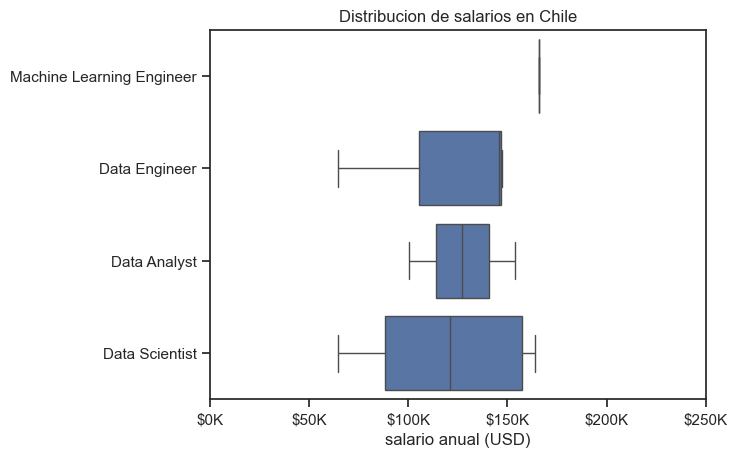

In [9]:
sns.boxplot(data=df_ch_top4, x='salary_year_avg', y='job_title_short', order=job_order)
sns.set_theme(style='ticks')

plt.title('Distribucion de salarios en Chile')
plt.xlabel('salario anual (USD)')
plt.ylabel('')
plt.xlim(0,250000)
ticks_x = plt.FuncFormatter(lambda y, pos: f'${int(y/1000)}K')
plt.gca().xaxis.set_major_formatter(ticks_x)
plt.show()

In [20]:
df_DS_ch = df[(df['job_country']== 'Chile') & (df['job_title_short'] == 'Data Scientist')].copy()

df_DS_ch = df_ch_top4.dropna(subset=['salary_year_avg'])

In [21]:
df_DS_ch = df_DS_ch.explode('job_skills')

df_DS_ch[['salary_year_avg','job_skills']].head(5)

,salary_year_avg,job_skills
6325,147500.0,python
6325,147500.0,mongo
6325,147500.0,gcp
6325,147500.0,databricks
6325,147500.0,kafka


In [43]:
df_DS_top_pay = df_DS_ch.groupby('job_skills')['salary_year_avg'].agg(['count', 'median']).sort_values(by='median', ascending=False)

df_DS_top_pay = df_DS_top_pay.head(10)

In [44]:
df_DS_skills = df_DS_ch.groupby('job_skills')['salary_year_avg'].agg(['count', 'median']).sort_values(by='count', ascending=False)

df_DS_skills = df_DS_skills.head(10).sort_values(by='median', ascending=False)

df_DS_skills

,count,median
job_skills,,
r,3,157500.0
power bi,4,150750.0
python,7,147500.0
pytorch,2,143500.0
tensorflow,2,143500.0
scikit-learn,2,139250.0
gcp,3,121000.0
aws,4,104564.0
sql,6,94314.0


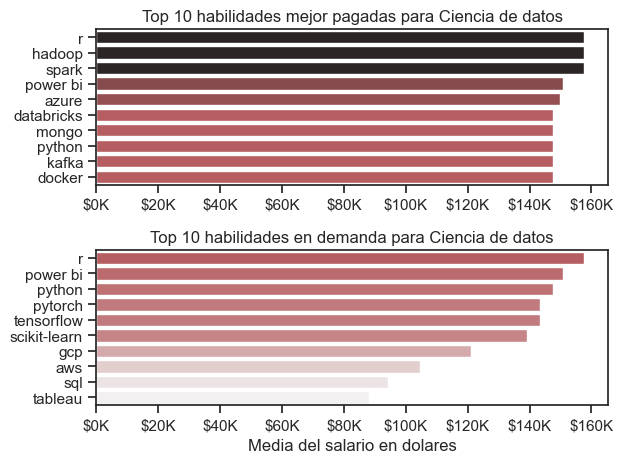

In [45]:
fig, ax = plt.subplots(2, 1)

sns.set_style('ticks')


sns.barplot(data=df_DS_top_pay, x='median', y=df_DS_top_pay.index, hue='median', ax=ax[0], palette='dark:r_r')
ax[0].legend().remove()
#df_DS_top_pay.plot(kind='barh', y='median', ax=ax[0], legend=False)
ax[0].set_title('Top 10 habilidades mejor pagadas para Ciencia de datos')
ax[0].set_ylabel('')
ax[0].set_xlabel('')
ax[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x , _: f'${int(x/1000)}K'))


sns.barplot(data=df_DS_skills, x='median', y=df_DS_skills.index, ax=ax[1], hue='median', palette='light:r')
ax[1].legend().remove()
#df_DA_skills.plot(kind='barh', y='median', ax=ax[1], legend=False)
ax[1].set_xlim((ax[0]).get_xlim())
ax[1].set_title('Top 10 habilidades en demanda para Ciencia de datos')
ax[1].set_ylabel('')
ax[1].set_xlabel('Media del salario en dolares')
ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x , _: f'${int(x/1000)}K'))


fig.tight_layout()
plt.show()